In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#This file is being read from the archived dataset in our zip folder. Please use this if running this notebook.
df = pd.read_csv('archived datasets/emissions_by_country_processed.csv')
df

,Country,ISO 3166-1 alpha-3,Year,Total,Temperature,GDP Per Capita (USD),Coal,Oil,Gas,Cement,Flaring,Other,Per Capita
0,AFGHANISTAN,AFG,1750.0,0.000000,70,55455,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
1,AFGHANISTAN,AFG,1751.0,0.000000,66,45101,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
2,AFGHANISTAN,AFG,1752.0,0.000000,72,31891,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
3,AFGHANISTAN,AFG,1753.0,0.000000,44,35466,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
4,AFGHANISTAN,AFG,1754.0,0.000000,21,33247,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63099,GLOBAL,WLD,2017.0,36096.739276,22,32659,14506.973805,12242.627935,7144.928128,1507.923185,391.992176,302.294047,4.749682
63100,GLOBAL,WLD,2018.0,36826.506600,44,21696,14746.830688,12266.016285,7529.846784,1569.218392,412.115746,302.478706,4.792753
63101,GLOBAL,WLD,2019.0,37082.558969,78,52918,14725.978025,12345.653374,7647.528220,1617.506786,439.253991,306.638573,4.775633
63102,GLOBAL,WLD,2020.0,35264.085734,34,39808,14174.564010,11191.808551,7556.290283,1637.537532,407.583673,296.301685,4.497423


In [ ]:
#Reusing my code from Assignment 0

#Country
Country  = pd.Categorical(df['Country'])
df['Country_categorical'] = Country.codes
df.drop('Country', axis=1, inplace=True)

ISO_code = pd.Categorical(df['ISO 3166-1 alpha-3'])
df['ISO_code_categorical'] = ISO_code.codes
df.drop('ISO 3166-1 alpha-3', axis=1, inplace=True)

df

,Year,Total,Temperature,GDP Per Capita (USD),Coal,Oil,Gas,Cement,Flaring,Other,Per Capita,Country_categorical,ISO_code_categorical
0,1750.0,0.000000,70,55455,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0,1
1,1751.0,0.000000,66,45101,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0,1
2,1752.0,0.000000,72,31891,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0,1
3,1753.0,0.000000,44,35466,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0,1
4,1754.0,0.000000,21,33247,127.387271,153.480038,125.162671,62.599364,56.074327,849.395127,121.565443,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63099,2017.0,36096.739276,22,32659,14506.973805,12242.627935,7144.928128,1507.923185,391.992176,302.294047,4.749682,79,217
63100,2018.0,36826.506600,44,21696,14746.830688,12266.016285,7529.846784,1569.218392,412.115746,302.478706,4.792753,79,217
63101,2019.0,37082.558969,78,52918,14725.978025,12345.653374,7647.528220,1617.506786,439.253991,306.638573,4.775633,79,217
63102,2020.0,35264.085734,34,39808,14174.564010,11191.808551,7556.290283,1637.537532,407.583673,296.301685,4.497423,79,217


In [ ]:
X = df.drop('Per Capita', axis = 1)
Y = df['Per Capita']

In [ ]:
#Checking both the shapes
print(X.shape)
print(Y.shape)

(63104, 12)
(63104,)


In [ ]:
#Generating permutation to randomly shuffle
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
print(indices)

[60892  7634 35657 ... 57584 22619 17884]


In [ ]:
X_train = X.iloc[indices[:train_size]]
Y_train = Y.iloc[indices[:train_size]]
X_test = X.iloc[indices[train_size:]]
Y_test = Y.iloc[indices[train_size:]]

print("Shape of X_train is", X_train.shape)
print("Shape of Y_train is", Y_train.shape)
print("Shape of X_test is", X_test.shape)
print("Shape of Y_test is", Y_test.shape)

Shape of X_train is (50483, 12)
Shape of Y_train is (50483,)
Shape of X_test is (12621, 12)
Shape of Y_test is (12621,)


In [ ]:
df.columns

Index(['Year', 'Total', 'Temperature', 'GDP Per Capita (USD)', 'Coal', 'Oil',
       'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita',
       'Country_categorical', 'ISO_code_categorical'],
      dtype='object')

In [ ]:
#Reusing my code from Assignment 0
columns = ['Total', 'Temperature', 'GDP Per Capita (USD)', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other',]
datasets = [X_train, X_test]
for dataset in datasets:
  for column in columns:
    max = dataset[column].max()
    min = dataset[column].min()
    dataset[column] = (dataset[column] - min) / (max - min)

In [ ]:
def LinearRegression(X, Y):
  weights = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(Y)
  return weights

In [ ]:
weights = LinearRegression(X_train, Y_train)

In [ ]:
y_pred = np.dot(X_test, weights)
y_pred

array([ 87.76928274,  93.7923957 , 159.25291223, ...,  81.27272712,
        85.33079767,  67.50147753])

In [ ]:
MSE = (1/len(Y_test)) * np.sum((Y_test - y_pred) ** 2)
print("MSE is", MSE)

MSE is 2646.3961202522787


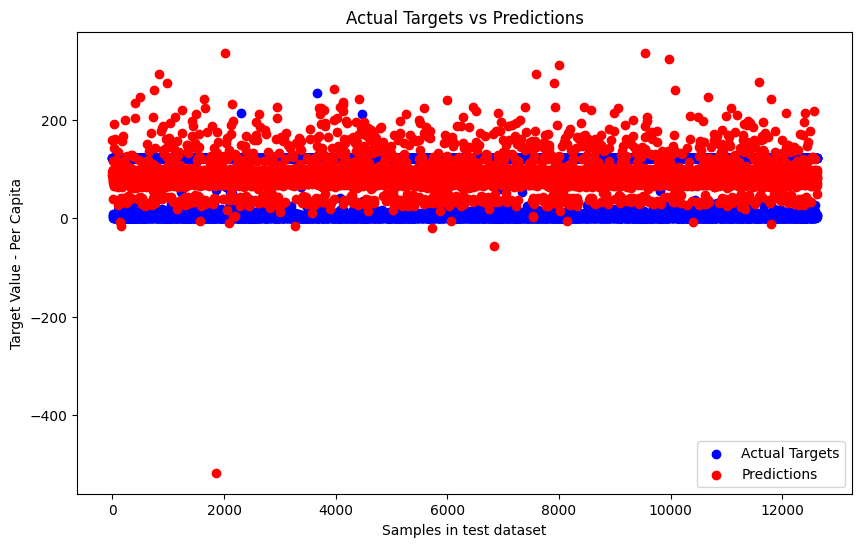

In [ ]:
test_samples = len(Y_test)

plt.figure(figsize=(10, 6))
plt.scatter(range(test_samples), Y_test, label='Actual Targets', color='blue')
plt.scatter(range(test_samples), y_pred, label='Predictions', color='red')
plt.xlabel('Samples in test dataset')
plt.ylabel('Target Value - Per Capita')
plt.title('Actual Targets vs Predictions')
plt.legend()
plt.show()

In [ ]:
import pickle
with open('linear_regression.pkl', 'wb') as f:
  pickle.dump(weights, f)